# 🏨 Hotel Demand Forecasting
**Option 1 — Daily Room Demand for 17 Hotel Properties**

**Forecast horizon:** h = 28 (next 4 weeks, daily)

### Models compared:
| Category | Models |
|---|---|
| Baseline | Naive, SeasonalNaive |
| StatsForecast | AutoETS, AutoARIMA |
| ML | LightGBM (mlforecast) |
| Neural | AutoNBEATS, AutoNHITS (neuralforecast) |
| Foundation | Chronos (timecopliot) |

### Evaluation:
- 5-fold time-series cross-validation (non-overlapping)
- Metrics: ME, MAE, RMSE, MAPE (where appropriate)
- Win counts per model per metric
- Final test forecasts saved as CSV
- Forecast vs. actual plots for each series

## 1. Install Dependencies

In [10]:
%%capture
!pip install statsforecast mlforecast neuralforecast utilsforecast
!pip install lightgbm
!pip install chronos-forecasting
!pip install pyarrow pandas matplotlib seaborn

## 2. Imports

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# StatsForecast
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

# MLForecast
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
import lightgbm as lgb

# NeuralForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

# Chronos (foundation model)
import torch
from chronos import BaseChronosPipeline

# Evaluation utilities
from utilsforecast.losses import mae, mse, rmse, mape
from utilsforecast.evaluation import evaluate

print("All imports successful ✅")
print(f"GPU available: {torch.cuda.is_available()}")

All imports successful ✅
GPU available: True


## 3. Load & Validate Data

In [12]:
# ── Upload your parquet file, then set this path ──────────────────────────────
# If running in Colab, upload via the Files panel (left sidebar)
# or mount Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   DATA_PATH = '/content/drive/MyDrive/sample_hotels.parquet'

DATA_PATH = 'sample_hotels-1.parquet'   # <-- update this if needed

df_raw = pd.read_parquet(DATA_PATH)
print("Raw shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()

Raw shape: (10172, 69)

Columns: ['unique_id', 'ds', 'holiday_flag', 'target_day', 'target_month', 'target_year', 'location_type', 'hotel_type', 'y', 'otb_1', 'otb_2', 'otb_3', 'otb_4', 'otb_5', 'otb_6', 'otb_7', 'otb_8', 'otb_9', 'otb_10', 'otb_11', 'otb_12', 'otb_13', 'otb_14', 'otb_15', 'otb_16', 'otb_17', 'otb_18', 'otb_19', 'otb_20', 'otb_21', 'otb_22', 'otb_23', 'otb_24', 'otb_25', 'otb_26', 'otb_27', 'otb_28', 'otb_29', 'otb_30', 'otb_31', 'otb_32', 'otb_33', 'otb_34', 'otb_35', 'otb_36', 'otb_37', 'otb_38', 'otb_39', 'otb_40', 'otb_41', 'otb_42', 'otb_43', 'otb_44', 'otb_45', 'otb_46', 'otb_47', 'otb_48', 'otb_49', 'otb_50', 'otb_51', 'otb_52', 'otb_53', 'otb_54', 'otb_55', 'otb_56', 'otb_57', 'otb_58', 'otb_59', 'otb_60']


,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
1430,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1431,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
1432,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
1433,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
1434,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


In [13]:
# ── Standardise to Nixtla long format ─────────────────────────────────────────
# Required columns: unique_id, ds (datetime), y (target)
# Adjust the column names below to match your actual dataset.

# --- EDIT THESE if your column names differ ---
ID_COL    = 'hotel_id'   # the series identifier column
DATE_COL  = 'date'       # the date column
TARGET    = 'demand'     # the target column (room demand)
# ----------------------------------------------

df = (
    df_raw
    .rename(columns={ID_COL: 'unique_id', DATE_COL: 'ds', TARGET: 'y'})
    [['unique_id', 'ds', 'y']]
    .assign(ds=lambda x: pd.to_datetime(x['ds']))
    .sort_values(['unique_id', 'ds'])
    .reset_index(drop=True)
)

print(f"Series (unique_id): {df['unique_id'].nunique()}")
print(f"Date range: {df['ds'].min()} → {df['ds'].max()}")
print(f"Total rows: {len(df):,}")
df.head()

Series (unique_id): 19
Date range: 2022-01-01 00:00:00 → 2023-06-30 00:00:00
Total rows: 10,172


,unique_id,ds,y
0,hotel_0,2022-01-01,0.975309
1,hotel_0,2022-01-02,0.493827
2,hotel_0,2022-01-03,0.456790
3,hotel_0,2022-01-04,0.592593
4,hotel_0,2022-01-05,0.530864


In [14]:
# ── Data quality checks ────────────────────────────────────────────────────────
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== Series lengths ===")
lengths = df.groupby('unique_id')['ds'].count()
print(lengths.describe())

print("\n=== Any zero/negative demand? ===")
print((df['y'] <= 0).sum(), "rows with y <= 0")

# MAPE will be unreliable if zeros exist
has_zeros = (df['y'] == 0).any()
print(f"\nMAPE appropriate? {'⚠️  No — zeros present, will skip MAPE' if has_zeros else '✅ Yes'}")

=== Missing values ===
unique_id    0
ds           0
y            0
dtype: int64

=== Series lengths ===
count     19.000000
mean     535.368421
std       46.341978
min      344.000000
25%      546.000000
50%      546.000000
75%      546.000000
max      546.000000
Name: ds, dtype: float64

=== Any zero/negative demand? ===
320 rows with y <= 0

MAPE appropriate? ⚠️  No — zeros present, will skip MAPE


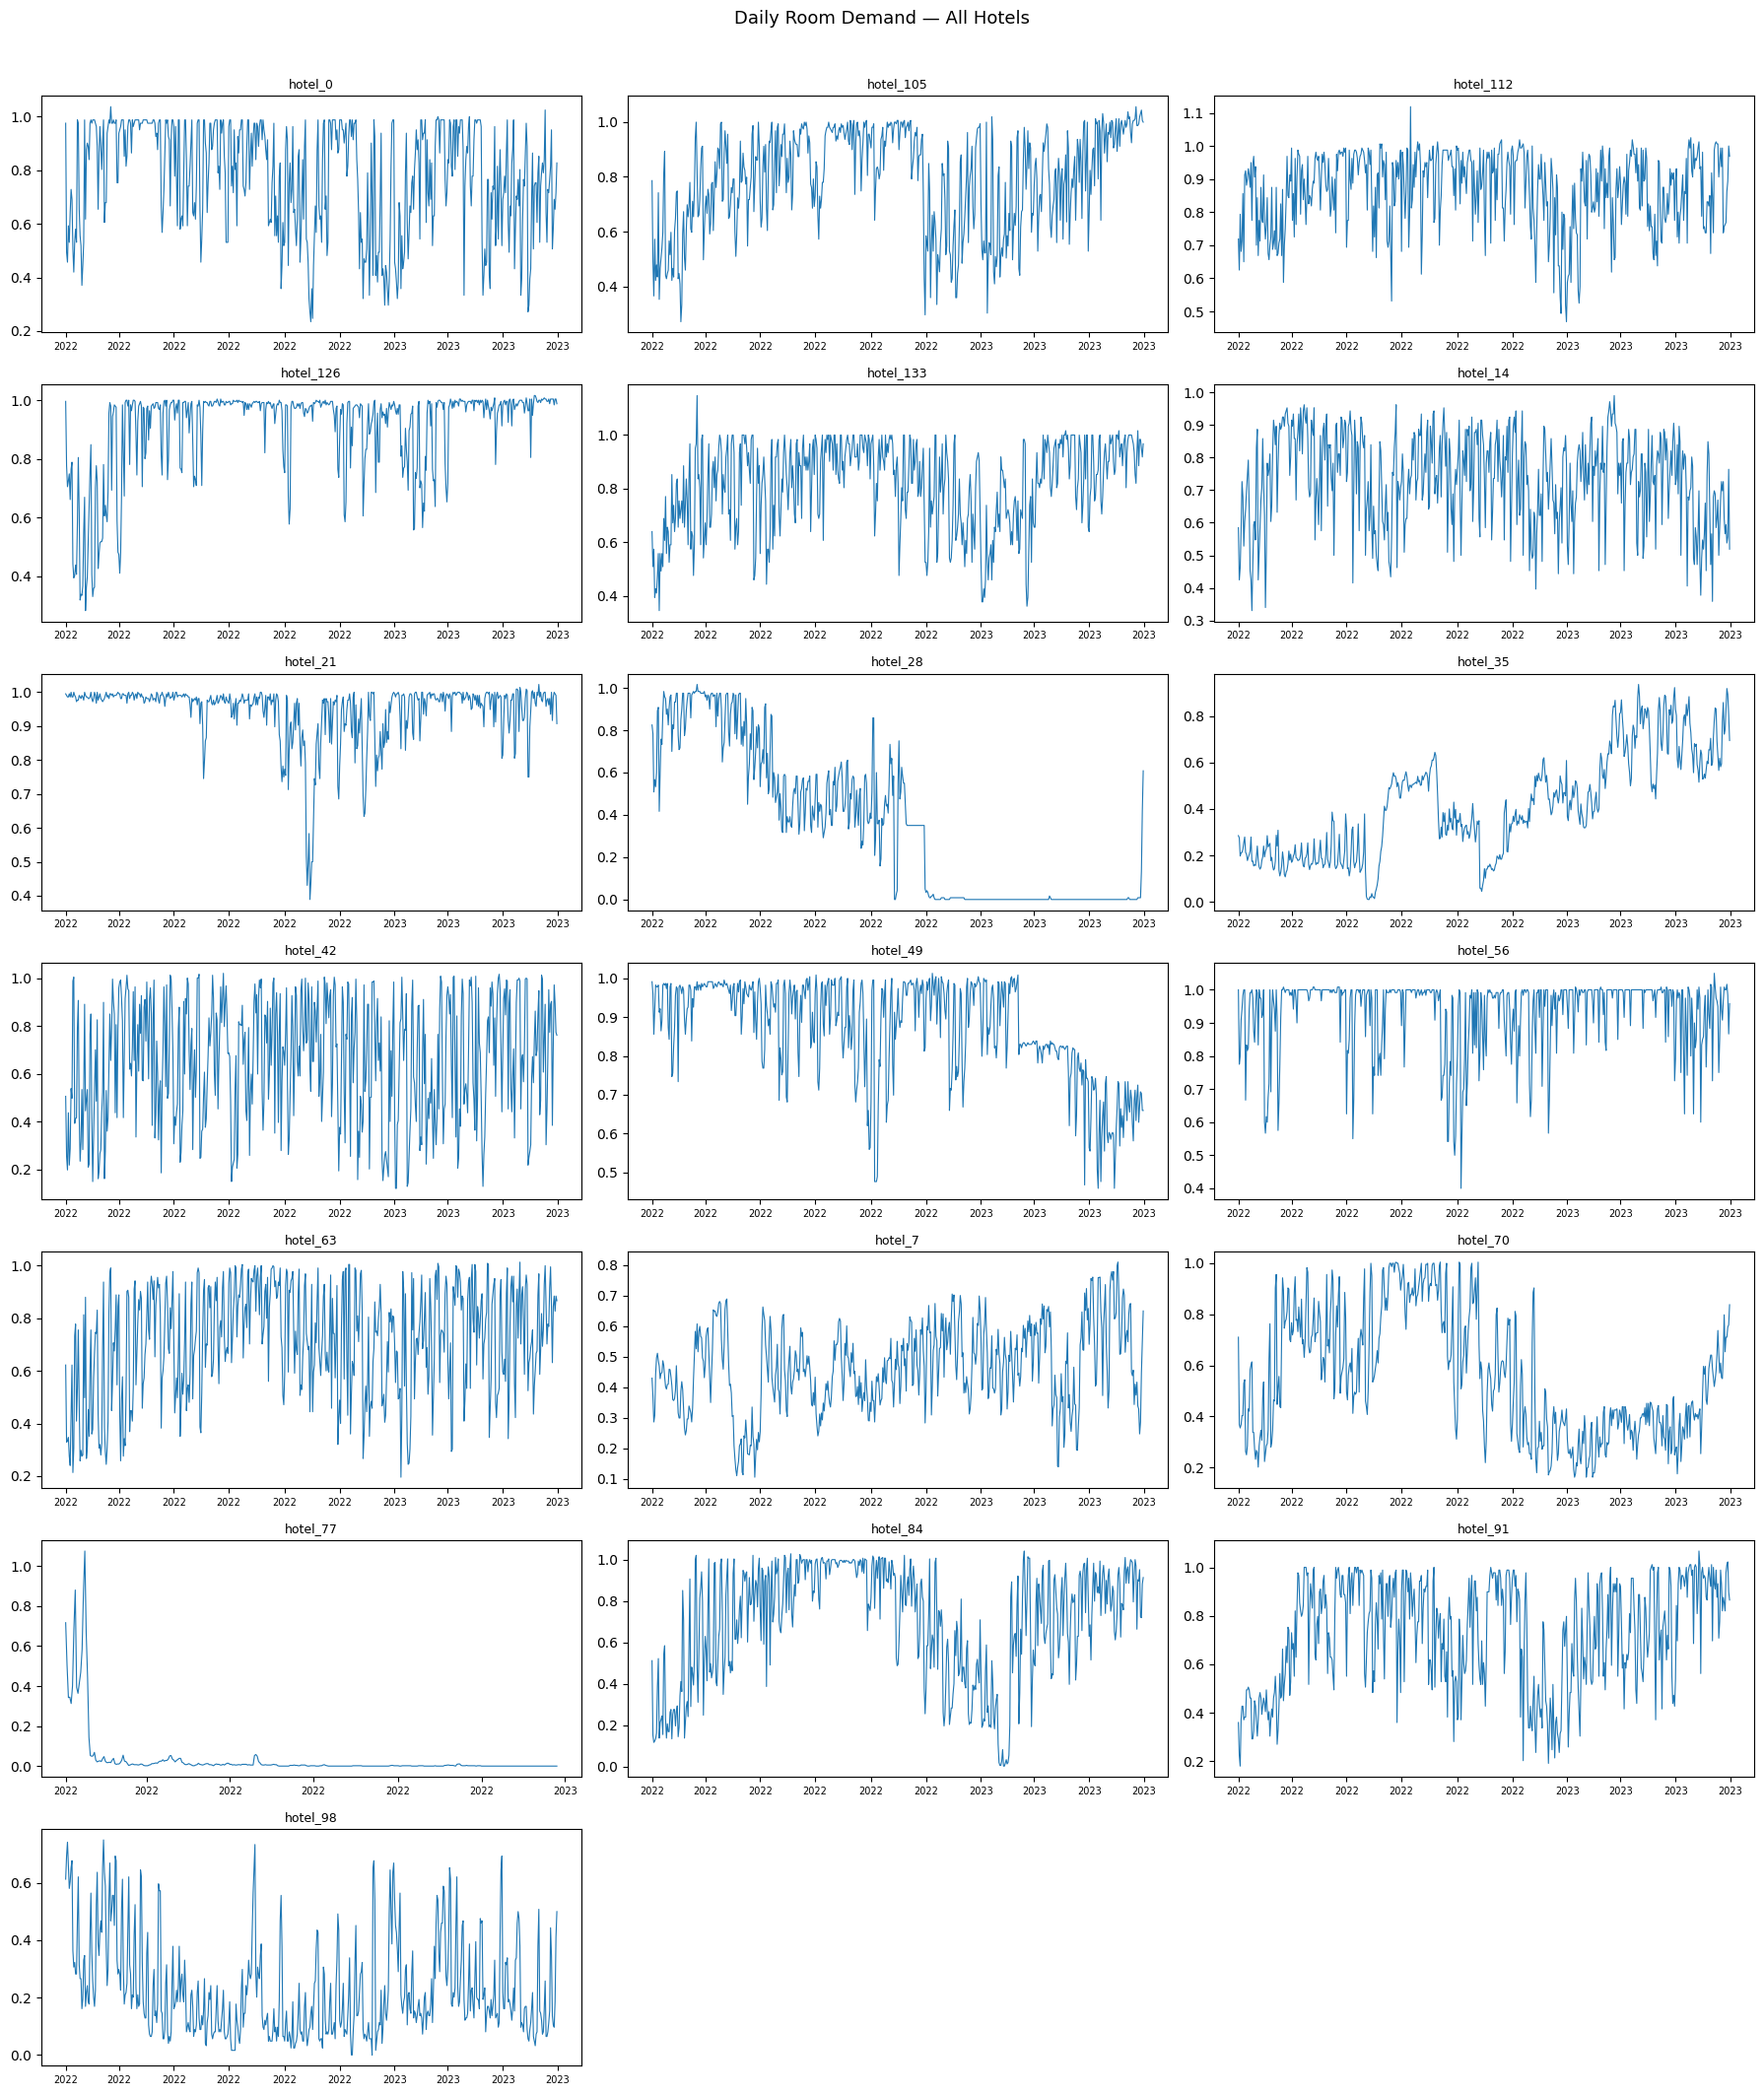

In [15]:
# ── Quick EDA: plot all 17 series ─────────────────────────────────────────────
n_series = df['unique_id'].nunique()
series_ids = df['unique_id'].unique()

fig, axes = plt.subplots(nrows=(n_series + 2) // 3, ncols=3,
                          figsize=(18, 3 * ((n_series + 2) // 3)))
axes = axes.flatten()

for i, uid in enumerate(series_ids):
    sub = df[df['unique_id'] == uid]
    axes[i].plot(sub['ds'], sub['y'], linewidth=0.8)
    axes[i].set_title(str(uid), fontsize=9)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Daily Room Demand — All Hotels', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_all_series.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Train / Test Split
Hold out the last **28 days** as the test set. Everything before is used for cross-validation.

In [21]:
H = 28
SEASON_LEN = 7

last_date = df['ds'].max()
cutoff = last_date - pd.Timedelta(days=H - 1)

df_train = df[df['ds'] < cutoff].copy()
df_test  = df[df['ds'] >= cutoff].copy()

# ── Diagnostic: check for gaps/duplicates before fixing ───────────────────────
print("=== Pre-fix diagnostics ===")
for uid, group in df_train.groupby('unique_id'):
    n_dupes = group['ds'].duplicated().sum()
    expected = (group['ds'].max() - group['ds'].min()).days + 1
    n_missing = expected - len(group)
    if n_dupes > 0 or n_missing > 0:
        print(f"  {uid}: {n_missing} missing dates, {n_dupes} duplicates")
print("Diagnostic complete.\n")

# ── Fill gaps and remove duplicates for all series ────────────────────────────
def fill_gaps(group):
    group = group.drop_duplicates(subset='ds')
    full_range = pd.date_range(start=group['ds'].min(), end=group['ds'].max(), freq='D')
    group = group.set_index('ds').reindex(full_range).rename_axis('ds').reset_index()
    group['unique_id'] = group['unique_id'].ffill()
    group['y'] = group['y'].interpolate(method='linear')
    return group

df_train = df_train.groupby('unique_id', group_keys=False).apply(fill_gaps).reset_index(drop=True)
df_test  = df_test.groupby('unique_id', group_keys=False).apply(fill_gaps).reset_index(drop=True)

# ── Verify all gaps resolved ──────────────────────────────────────────────────
gaps = df_train.groupby('unique_id').apply(
    lambda g: (g['ds'].max() - g['ds'].min()).days + 1 - len(g)
)
print("Remaining gaps per series (should all be 0):")
print("None ✅" if (gaps == 0).all() else gaps[gaps > 0])

print(f"\nTrain: {df_train['ds'].min()} → {df_train['ds'].max()} | {len(df_train):,} rows")
print(f"Test : {df_test['ds'].min()} → {df_test['ds'].max()} | {len(df_test):,} rows")

=== Pre-fix diagnostics ===
  hotel_77: 16 missing dates, 0 duplicates
Diagnostic complete.

Remaining gaps per series (should all be 0):
None ✅

Train: 2022-01-01 00:00:00 → 2023-06-02 00:00:00 | 9,684 rows
Test : 2023-06-03 00:00:00 → 2023-06-30 00:00:00 | 504 rows


## 5. Cross-Validation Setup
5-fold, non-overlapping time-series CV using `StatsForecast.cross_validation`.

Each fold steps forward by `H` days (non-overlapping).

In [17]:
N_FOLDS = 5

# For non-overlapping folds: step = H
# n_windows = N_FOLDS, step_size = H
# This means the 5 folds each cover a different H-length window, no overlap.
print(f"CV config: {N_FOLDS} folds, horizon={H}, step={H} (non-overlapping)")

CV config: 5 folds, horizon=28, step=28 (non-overlapping)


## 6. Baseline & StatsForecast Models

In [19]:
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

# Fast models (Naive, SeasonalNaive, AutoETS)
fast_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON_LEN),
    AutoETS(season_length=SEASON_LEN),
]

sf_fast = StatsForecast(
    models=fast_models,
    freq='D',
    n_jobs=-1,
    verbose=True
)

print("Running fast models CV (Naive, SeasonalNaive, AutoETS)...")
cv_fast = sf_fast.cross_validation(
    df=df_train,
    h=H,
    n_windows=N_FOLDS,
    step_size=H,
    refit=False
)
print("Fast models done! Shape:", cv_fast.shape)

# AutoARIMA separately with restricted search space
sf_arima = StatsForecast(
    models=[AutoARIMA(
        season_length=SEASON_LEN,
        max_p=3, max_q=3,
        max_P=1, max_Q=1,
        stepwise=True
    )],
    freq='D',
    n_jobs=-1,
    verbose=True
)

print("\nRunning AutoARIMA CV (this may take a few minutes)...")
cv_arima = sf_arima.cross_validation(
    df=df_train,
    h=H,
    n_windows=N_FOLDS,
    step_size=H,
    refit=False
)
print("AutoARIMA done! Shape:", cv_arima.shape)

# Merge into single cv_stats dataframe
cv_stats = cv_fast.merge(
    cv_arima[['unique_id', 'ds', 'cutoff', 'AutoARIMA']],
    on=['unique_id', 'ds', 'cutoff'],
    how='left'
)

print("\nMerged cv_stats shape:", cv_stats.shape)
print("Columns:", cv_stats.columns.tolist())
cv_stats.head()

Running fast models CV (Naive, SeasonalNaive, AutoETS)...
Fast models done! Shape: (2660, 7)

Running AutoARIMA CV (this may take a few minutes)...
AutoARIMA done! Shape: (2660, 5)

Merged cv_stats shape: (2660, 8)
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA']


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,2023-01-14,2023-01-13,0.938272,0.790123,0.629630,0.761871,0.718389
1,hotel_0,2023-01-15,2023-01-13,0.604938,0.790123,0.358025,0.561969,0.595617
2,hotel_0,2023-01-16,2023-01-13,0.469136,0.790123,0.555556,0.568555,0.640361
3,hotel_0,2023-01-17,2023-01-13,0.567901,0.790123,0.432099,0.583771,0.582623
4,hotel_0,2023-01-18,2023-01-13,0.666667,0.790123,0.456790,0.573340,0.581835


## 7. ML Model — LightGBM (MLForecast)

In [22]:
from mlforecast.lag_transforms import RollingMean, RollingStd

mlf = MLForecast(
    models={'LightGBM': lgb.LGBMRegressor(n_estimators=100, verbosity=-1)},
    freq='D',
    lags=[1, 7, 14, 28],
    lag_transforms={
        1: [RollingMean(window_size=7), RollingStd(window_size=7)],
        7: [RollingMean(window_size=28)],
    },
    date_features=['dayofweek', 'month', 'quarter'],
    target_transforms=[Differences([1, 7])],
)

print("Running MLForecast cross-validation...")
cv_lgbm = mlf.cross_validation(
    df=df_train,
    h=H,
    n_windows=N_FOLDS,
    step_size=H,
    refit=True
)

print("Done! Shape:", cv_lgbm.shape)
cv_lgbm.head()

Running MLForecast cross-validation...
Done! Shape: (2660, 5)


,unique_id,ds,cutoff,y,LightGBM
0,hotel_0,2023-01-14,2023-01-13,0.938272,0.800459
1,hotel_0,2023-01-15,2023-01-13,0.604938,0.468952
2,hotel_0,2023-01-16,2023-01-13,0.469136,0.534396
3,hotel_0,2023-01-17,2023-01-13,0.567901,0.516138
4,hotel_0,2023-01-18,2023-01-13,0.666667,0.535317


## 8. Neural Models — AutoNBEATS & AutoNHITS (NeuralForecast)
> ⏱️ This cell may take 10–20 minutes. A T4 GPU is recommended (Runtime → Change runtime type).

In [24]:
neural_models = [
    NBEATS(
        h=H,
        input_size=2 * H,
        max_steps=500,
        val_check_steps=50,
        early_stop_patience_steps=-1,   # -1 disables early stopping entirely
    ),
    NHITS(
        h=H,
        input_size=2 * H,
        max_steps=500,
        val_check_steps=50,
        early_stop_patience_steps=-1,   # -1 disables early stopping entirely
    ),
]

nf = NeuralForecast(models=neural_models, freq='D')

print("Running NeuralForecast cross-validation...")
cv_neural = nf.cross_validation(
    df=df_train,
    n_windows=N_FOLDS,
    step_size=H,
    refit=True,
    val_size=H,       # reserve last H timesteps of each fold as validation set
)

print("Done! Shape:", cv_neural.shape)
cv_neural.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running NeuralForecast cross-validation...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 4.8 K                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Done! Shape: (2660, 6)


,unique_id,ds,cutoff,NBEATS,NHITS,y
0,hotel_0,2023-01-14,2023-01-13,0.776984,0.766131,0.938272
1,hotel_0,2023-01-15,2023-01-13,0.335177,0.484453,0.604938
2,hotel_0,2023-01-16,2023-01-13,0.301559,0.495231,0.469136
3,hotel_0,2023-01-17,2023-01-13,0.367628,0.539518,0.567901
4,hotel_0,2023-01-18,2023-01-13,0.425485,0.546230,0.666667


## 9. Foundation Model — Chronos
> Uses `amazon/chronos-t5-small` (no API key required). Inference only — no training needed.

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Loading Chronos on {device}...")

chronos_pipeline = BaseChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map=device,
    torch_dtype=torch.bfloat16,
)
print("Chronos loaded ✅")

Loading Chronos on cuda...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos loaded ✅


In [27]:
def chronos_cv(df_train: pd.DataFrame, n_windows: int, h: int, step_size: int) -> pd.DataFrame:
    """
    Manual 5-fold CV for Chronos (non-overlapping).
    Returns a dataframe in the same format as StatsForecast cv output.
    """
    records = []
    global_max = df_train['ds'].max()

    fold_cutoffs = [
        global_max - pd.Timedelta(days=step_size * (n_windows - fold))
        for fold in range(n_windows)
    ]

    for cutoff in fold_cutoffs:
        fold_train = df_train[df_train['ds'] <= cutoff]
        fold_test_start = cutoff + pd.Timedelta(days=1)

        for uid in df_train['unique_id'].unique():
            series = fold_train[fold_train['unique_id'] == uid]['y'].values
            if len(series) < 2:
                continue

            context = torch.tensor(series, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                forecast = chronos_pipeline.predict(
                    context,          # positional argument, not keyword
                    prediction_length=h,
                    num_samples=20
                )
            preds = forecast[0].median(dim=0).values.cpu().numpy()

            future_dates = pd.date_range(start=fold_test_start, periods=h, freq='D')
            for date, pred in zip(future_dates, preds):
                records.append({
                    'unique_id': uid,
                    'ds': date,
                    'cutoff': cutoff,
                    'Chronos': float(pred)
                })

    return pd.DataFrame(records)


print("Running Chronos CV (this may take a few minutes)...")
cv_chronos = chronos_cv(df_train, n_windows=N_FOLDS, h=H, step_size=H)

# Merge actuals
cv_chronos = cv_chronos.merge(
    df_train[['unique_id', 'ds', 'y']],
    on=['unique_id', 'ds'],
    how='left'
)
print("Done! Shape:", cv_chronos.shape)
cv_chronos.head()


Running Chronos CV (this may take a few minutes)...
Done! Shape: (2660, 5)


,unique_id,ds,cutoff,Chronos,y
0,hotel_0,2023-01-14,2023-01-13,0.792453,0.938272
1,hotel_0,2023-01-15,2023-01-13,0.677604,0.604938
2,hotel_0,2023-01-16,2023-01-13,0.666120,0.469136
3,hotel_0,2023-01-17,2023-01-13,0.689089,0.567901
4,hotel_0,2023-01-18,2023-01-13,0.654635,0.666667


## 10. Merge All CV Results

In [31]:
key_cols = ['unique_id', 'ds', 'cutoff', 'y']
stats_model_cols = ['Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA']
lgbm_col    = ['LightGBM']
neural_cols = ['NBEATS', 'NHITS']
chronos_col = ['Chronos']

# Reset index on all CV dataframes before merging
cv_stats   = cv_stats.reset_index()   if 'unique_id' not in cv_stats.columns   else cv_stats
cv_lgbm    = cv_lgbm.reset_index()    if 'unique_id' not in cv_lgbm.columns    else cv_lgbm
cv_neural  = cv_neural.reset_index()  if 'unique_id' not in cv_neural.columns  else cv_neural
cv_chronos = cv_chronos.reset_index() if 'unique_id' not in cv_chronos.columns else cv_chronos

cv_all = (
    cv_stats[key_cols + stats_model_cols]
    .merge(cv_lgbm[key_cols + lgbm_col],      on=key_cols, how='outer')
    .merge(cv_neural[key_cols + neural_cols],  on=key_cols, how='outer')
    .merge(cv_chronos[key_cols + chronos_col], on=key_cols, how='outer')
)

# Guarantee unique_id is a plain column
cv_all = cv_all.reset_index(drop=True)

MODEL_COLS = stats_model_cols + lgbm_col + neural_cols + chronos_col

print("Merged CV shape:", cv_all.shape)
print("Columns:", cv_all.columns.tolist())
print("unique_id is a column:", 'unique_id' in cv_all.columns)
cv_all.head()

Merged CV shape: (2940, 12)
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA', 'LightGBM', 'NBEATS', 'NHITS', 'Chronos']
unique_id is a column: True


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA,LightGBM,NBEATS,NHITS,Chronos
0,hotel_0,2023-01-14,2023-01-13,0.938272,0.790123,0.629630,0.761871,0.718389,0.800459,0.776984,0.766131,0.792453
1,hotel_0,2023-01-15,2023-01-13,0.604938,0.790123,0.358025,0.561969,0.595617,0.468952,0.335177,0.484453,0.677604
2,hotel_0,2023-01-16,2023-01-13,0.469136,0.790123,0.555556,0.568555,0.640361,0.534396,0.301559,0.495231,0.666120
3,hotel_0,2023-01-17,2023-01-13,0.567901,0.790123,0.432099,0.583771,0.582623,0.516138,0.367628,0.539518,0.689089
4,hotel_0,2023-01-18,2023-01-13,0.666667,0.790123,0.456790,0.573340,0.581835,0.535317,0.425485,0.546230,0.654635


## 11. Evaluate — ME, MAE, RMSE, MAPE

In [33]:
cv_all = cv_all.reset_index(drop=True) if 'unique_id' in cv_all.columns else cv_all.reset_index()

# Check if MAPE is safe (no zeros in y)
use_mape = not (cv_all['y'] == 0).any()
print(f"Using MAPE: {use_mape}")

def compute_me(df, model_cols):
    """Mean Error (bias) — computed manually."""
    results = []
    for uid, grp in df.groupby('unique_id'):
        row = {'unique_id': uid}
        for m in model_cols:
            row[m] = (grp[m] - grp['y']).mean()
        results.append(row)
    return pd.DataFrame(results).set_index('unique_id')

def compute_metric(df, metric_fn, model_cols):
    """Compute a utilsforecast metric per series per model."""
    records = []
    for uid, grp in df.groupby('unique_id'):
        row = {'unique_id': uid}
        for m in model_cols:
            # Include 'unique_id' when passing to metric_fn
            sub = grp[['unique_id', 'y', m]].dropna().reset_index(drop=True)
            if len(sub) == 0:
                row[m] = np.nan
            else:
                row[m] = metric_fn(sub, models=[m], target_col='y')[m].values[0]
        records.append(row)
    return pd.DataFrame(records).set_index('unique_id')

me_df   = compute_me(cv_all, MODEL_COLS)
mae_df  = compute_metric(cv_all, mae,  MODEL_COLS)
rmse_df = compute_metric(cv_all, rmse, MODEL_COLS)

if use_mape:
    mape_df = compute_metric(cv_all, mape, MODEL_COLS)
else:
    mape_df = pd.DataFrame(index=me_df.index, columns=MODEL_COLS, dtype=float)
    mape_df[:] = np.nan
    print("MAPE skipped — zeros present in target series.")

print("\n=== MAE (lower is better) ===")
mae_df.round(2)

Using MAPE: False
MAPE skipped — zeros present in target series.

=== MAE (lower is better) ===


,Naive,SeasonalNaive,AutoETS,AutoARIMA,LightGBM,NBEATS,NHITS,Chronos
unique_id,,,,,,,,
hotel_0,0.20,0.21,0.18,0.18,0.19,0.23,0.19,0.18
hotel_105,0.19,0.12,0.11,0.11,0.13,0.13,0.19,0.12
hotel_112,0.18,0.12,0.12,0.11,0.25,0.12,0.11,0.10
hotel_126,0.06,0.06,0.07,0.06,0.12,0.07,0.07,0.06
hotel_133,0.15,0.13,0.14,0.12,0.20,0.11,0.12,0.13
hotel_14,0.15,0.11,0.10,0.10,0.18,0.10,0.08,0.09
hotel_21,0.05,0.04,0.05,0.05,0.14,0.03,0.03,0.03
hotel_28,0.00,0.00,0.06,0.00,0.04,0.00,0.00,0.00
hotel_35,0.15,0.16,0.15,0.15,0.22,0.12,0.13,0.14


In [34]:
# ── Full cross-validation results table ───────────────────────────────────────
me_df.columns   = pd.MultiIndex.from_product([['ME'],   me_df.columns])
mae_df.columns  = pd.MultiIndex.from_product([['MAE'],  mae_df.columns])
rmse_df.columns = pd.MultiIndex.from_product([['RMSE'], rmse_df.columns])
mape_df.columns = pd.MultiIndex.from_product([['MAPE'], mape_df.columns])

cv_results = pd.concat([me_df, mae_df, rmse_df, mape_df], axis=1)
cv_results.to_csv('cv_results_per_series.csv')
print("Saved: cv_results_per_series.csv")
cv_results.round(2)

Saved: cv_results_per_series.csv


ME                                                                \
          Naive SeasonalNaive AutoETS AutoARIMA LightGBM NBEATS NHITS Chronos   
unique_id                                                                       
hotel_0    0.09          0.01   -0.00     -0.01    -0.03  -0.05 -0.04    0.14   
hotel_105  0.14         -0.06   -0.02     -0.00    -0.01  -0.04  0.01    0.05   
hotel_112 -0.10         -0.04   -0.06     -0.05    -0.17  -0.06 -0.05    0.01   
hotel_126  0.03          0.01   -0.02      0.01     0.03   0.02  0.02    0.05   
hotel_133 -0.04         -0.05   -0.08     -0.06    -0.06  -0.03 -0.03   -0.05   
hotel_14   0.07         -0.00    0.02      0.00    -0.05  -0.01 -0.01    0.01   
hotel_21  -0.01         -0.01   -0.02     -0.03    -0.12   0.00  0.00    0.02   
hotel_28  -0.00         -0.00   -0.04     -0.00    -0.04  -0.00 -0.00   -0.00   
hotel_35  -0.12         -0.05   -0.11     -0.11    -0.20  -0.03 -0.08   -0.09   
hotel_42  -0.03          0.04   -0.03      0.01    -0.03   0.02 -0.05    0.23   
hotel_49   0.08          0.05    0.03      0.07    -0.02   0.03  0.06    0.08   
hotel_56   0.01          0.01   -0.01     -0.03    -0.08  -0.00  0.00    0.04   
hotel_63   0.16         -0.02    0.03     -0.01    -0.07   0.01 -0.01    0.09   
hotel_7    0.12          0.01    0.01     -0.01    -0.06  -0.04 -0.02    0.02   
hotel_70  -0.00         -0.03   -0.10     -0.03    -0.13   0.01 -0.03    0.01   
hotel_77   0.00          0.00    0.00      0.00    -0.01  -0.00 -0.00     NaN   
hotel_84   0.09          0.00   -0.03     -0.05     0.18   0.02  0.00    0.07   
hotel_91  -0.03         -0.03   -0.04     -0.04    -0.01  -0.04 -0.07    0.05   
hotel_98   0.09          0.02    0.02      0.02    -0.04  -0.01 -0.02   -0.02   

            MAE                ...  RMSE          MAPE                        \
          Naive SeasonalNaive  ... NHITS Chronos Naive SeasonalNaive AutoETS   
unique_id                      ...                                             
hotel_0    0.20          0.21  ...  0.23    0.24   NaN           NaN     NaN   
hotel_105  0.19          0.12  ...  0.23    0.15   NaN           NaN     NaN   
hotel_112  0.18          0.12  ...  0.13    0.12   NaN           NaN     NaN   
hotel_126  0.06          0.06  ...  0.10    0.12   NaN           NaN     NaN   
hotel_133  0.15          0.13  ...  0.15    0.16   NaN           NaN     NaN   
hotel_14   0.15          0.11  ...  0.10    0.12   NaN           NaN     NaN   
hotel_21   0.05          0.04  ...  0.05    0.05   NaN           NaN     NaN   
hotel_28   0.00          0.00  ...  0.00    0.00   NaN           NaN     NaN   
hotel_35   0.15          0.16  ...  0.16    0.17   NaN           NaN     NaN   
hotel_42   0.30          0.27  ...  0.36    0.35   NaN           NaN     NaN   
hotel_49   0.10          0.09  ...  0.12    0.12   NaN           NaN     NaN   
hotel_56   0.06          0.04  ...  0.08    0.09   NaN           NaN     NaN   
hotel_63   0.20          0.20  ...  0.22    0.23   NaN           NaN     NaN   
hotel_7    0.14          0.11  ...  0.13    0.13   NaN           NaN     NaN   
hotel_70   0.06          0.09  ...  0.14    0.08   NaN           NaN     NaN   
hotel_77   0.00          0.00  ...  0.00     NaN   NaN           NaN     NaN   
hotel_84   0.20          0.18  ...  0.25    0.22   NaN           NaN     NaN   
hotel_91   0.19          0.19  ...  0.24    0.19   NaN           NaN     NaN   
hotel_98   0.19          0.15  ...  0.18    0.17   NaN           NaN     NaN   

                                                   
          AutoARIMA LightGBM NBEATS NHITS Chronos  
unique_id                                          
hotel_0         NaN      NaN    NaN   NaN     NaN  
hotel_105       NaN      NaN    NaN   NaN     NaN  
hotel_112       NaN      NaN    NaN   NaN     NaN  
hotel_126       NaN      NaN    NaN   NaN     NaN  
hotel_133       NaN      NaN    NaN   NaN     NaN  
hotel_14        NaN      NaN    NaN   NaN     NaN  
h

## 12. Win Counts — Which Model Wins Most Often?

In [35]:
# Reset column index for easier access
me_flat   = me_df.copy();   me_flat.columns   = me_df.columns.get_level_values(1)
mae_flat  = mae_df.copy();  mae_flat.columns  = mae_df.columns.get_level_values(1)
rmse_flat = rmse_df.copy(); rmse_flat.columns = rmse_df.columns.get_level_values(1)
mape_flat = mape_df.copy(); mape_flat.columns = mape_df.columns.get_level_values(1)

def win_counts(metric_df, metric_name, higher_better=False):
    """Count how many series each model wins (lowest value = win)."""
    if higher_better:
        winners = metric_df.idxmax(axis=1)
    else:
        winners = metric_df.abs().idxmin(axis=1)  # abs for ME (lowest bias magnitude)
    counts = winners.value_counts().reindex(MODEL_COLS, fill_value=0)
    counts.name = metric_name
    return counts

wins = pd.DataFrame({
    'ME (lowest |bias|)': win_counts(me_flat,   'ME'),
    'MAE':                win_counts(mae_flat,  'MAE'),
    'RMSE':               win_counts(rmse_flat, 'RMSE'),
    'MAPE':               win_counts(mape_flat, 'MAPE') if use_mape else pd.Series(0, index=MODEL_COLS),
})

wins.to_csv('cv_win_counts.csv')
print("Saved: cv_win_counts.csv")
print("\n=== Model Win Counts ===")
wins

Saved: cv_win_counts.csv

=== Model Win Counts ===


,ME (lowest |bias|),MAE,RMSE,MAPE
Naive,1,3,1,0
SeasonalNaive,3,1,1,0
AutoETS,1,4,4,0
AutoARIMA,3,2,5,0
LightGBM,2,0,0,0
NBEATS,3,2,2,0
NHITS,4,2,2,0
Chronos,2,5,4,0


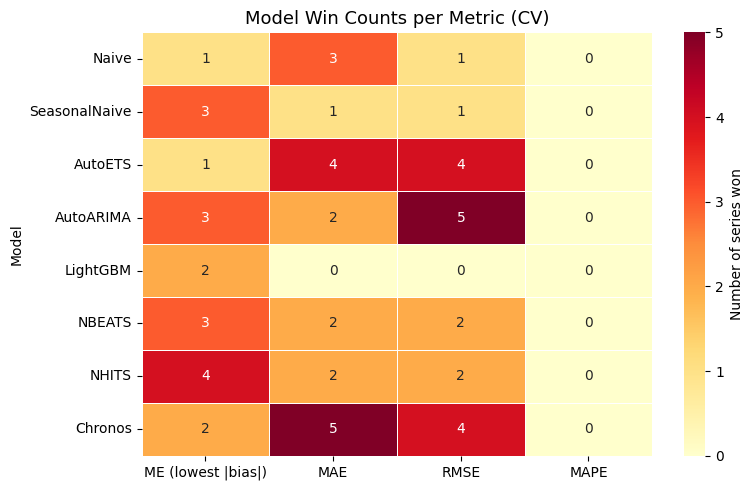

In [36]:
# ── Heatmap of win counts ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    wins, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of series won'}
)
ax.set_title('Model Win Counts per Metric (CV)', fontsize=13)
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('win_counts_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Final Test Forecasts

In [37]:
# ── StatsForecast: refit on full train, predict test horizon ──────────────────
sf.fit(df=df_train)
test_stats = sf.predict(h=H)
print("StatsForecast test forecasts shape:", test_stats.shape)

StatsForecast test forecasts shape: (532, 6)


In [38]:
# ── MLForecast: refit & predict ───────────────────────────────────────────────
mlf.fit(df=df_train)
test_lgbm = mlf.predict(h=H)
print("LightGBM test forecasts shape:", test_lgbm.shape)

LightGBM test forecasts shape: (532, 3)


In [39]:
# ── NeuralForecast: refit & predict ──────────────────────────────────────────
nf.fit(df=df_train)
test_neural = nf.predict()
print("Neural test forecasts shape:", test_neural.shape)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 4.8 K                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Neural test forecasts shape: (532, 4)


In [42]:
# ── Chronos: predict from full train ─────────────────────────────────────────
chronos_test_records = []
for uid in df_train['unique_id'].unique():
    series = df_train[df_train['unique_id'] == uid]['y'].values
    context = torch.tensor(series, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        forecast = chronos_pipeline.predict(
            context,                  # positional argument, not keyword
            prediction_length=H,
            num_samples=20
        )
    preds = forecast[0].median(dim=0).values.cpu().numpy()
    future_dates = pd.date_range(
        start=df_train[df_train['unique_id'] == uid]['ds'].max() + pd.Timedelta(days=1),
        periods=H, freq='D'
    )
    for d, p in zip(future_dates, preds):
        chronos_test_records.append({'unique_id': uid, 'ds': d, 'Chronos': float(p)})

test_chronos = pd.DataFrame(chronos_test_records)
print("Chronos test forecasts shape:", test_chronos.shape)

Chronos test forecasts shape: (532, 3)


In [46]:
# Reset index on all test forecast dataframes before merging
test_stats   = test_stats.reset_index()   if 'unique_id' not in test_stats.columns   else test_stats
test_lgbm    = test_lgbm.reset_index()    if 'unique_id' not in test_lgbm.columns    else test_lgbm
test_neural  = test_neural.reset_index()  if 'unique_id' not in test_neural.columns  else test_neural

test_all = (
    test_stats
    .merge(test_lgbm,   on=['unique_id', 'ds'], how='outer')
    .merge(test_neural, on=['unique_id', 'ds'], how='outer')
    .merge(test_chronos, on=['unique_id', 'ds'], how='outer')
    .merge(df_test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
)

# Guarantee unique_id is a plain column
test_all = test_all.reset_index(drop=True)

test_all.to_csv('test_forecasts.csv', index=False)
print("Saved: test_forecasts.csv")
print("Columns:", test_all.columns.tolist())
print("unique_id is a column:", 'unique_id' in test_all.columns)
test_all.head()


Saved: test_forecasts.csv
Columns: ['unique_id', 'ds', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA', 'LightGBM', 'NBEATS', 'NHITS', 'Chronos', 'y']
unique_id is a column: True


,unique_id,ds,Naive,SeasonalNaive,AutoETS,AutoARIMA,LightGBM,NBEATS,NHITS,Chronos,y
0,hotel_0,2023-06-03,0.691358,0.975309,0.665170,0.761467,0.781192,0.820084,0.807155,0.790292,0.864198
1,hotel_0,2023-06-04,0.691358,0.888889,0.446198,0.629696,0.433915,0.540403,0.494119,0.841833,0.506173
2,hotel_0,2023-06-05,0.691358,0.271605,0.463018,0.455322,0.487672,0.817095,0.571505,0.664304,0.740741
3,hotel_0,2023-06-06,0.691358,0.296296,0.497479,0.513527,0.623938,0.830616,0.520946,0.664304,0.753086
4,hotel_0,2023-06-07,0.691358,0.395062,0.494638,0.577492,0.675975,0.720471,0.407274,0.692937,0.753086


## 14. Test Set Metrics

In [49]:
def test_metrics(df, model_cols, use_mape=True):
    rows = []
    for uid, grp in df.groupby('unique_id'):
        row = {'unique_id': uid}
        for m in model_cols:
            sub = grp[['y', m]].dropna().reset_index(drop=True)
            if len(sub) == 0:
                row[f'{m}_ME']   = np.nan
                row[f'{m}_MAE']  = np.nan
                row[f'{m}_RMSE'] = np.nan
                row[f'{m}_MAPE'] = np.nan
                continue
            errors = sub[m] - sub['y']
            row[f'{m}_ME']   = float(errors.mean())
            row[f'{m}_MAE']  = float(errors.abs().mean())
            row[f'{m}_RMSE'] = float(np.sqrt((errors ** 2).mean()))
            row[f'{m}_MAPE'] = float((errors.abs() / sub['y'].abs()).mean()) if use_mape else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('unique_id')

test_metrics_df = test_metrics(test_all, MODEL_COLS, use_mape=use_mape)
test_metrics_df.to_csv('test_metrics_per_series.csv')

summary = test_metrics_df.mean().to_frame('mean').T
summary.to_csv('test_metrics_summary.csv')
print("Saved: test_metrics_per_series.csv & test_metrics_summary.csv")
summary.round(2)

Saved: test_metrics_per_series.csv & test_metrics_summary.csv


,Naive_ME,Naive_MAE,Naive_RMSE,Naive_MAPE,SeasonalNaive_ME,SeasonalNaive_MAE,SeasonalNaive_RMSE,SeasonalNaive_MAPE,AutoETS_ME,AutoETS_MAE,...,NBEATS_RMSE,NBEATS_MAPE,NHITS_ME,NHITS_MAE,NHITS_RMSE,NHITS_MAPE,Chronos_ME,Chronos_MAE,Chronos_RMSE,Chronos_MAPE
mean,-0.01,0.1,0.13,NaN,-0.06,0.14,0.18,NaN,-0.07,0.11,...,0.14,NaN,-0.01,0.1,0.13,NaN,0.0,0.1,0.13,NaN


In [50]:
# ── Summary: mean across all series ───────────────────────────────────────────
summary = test_metrics_df.mean().to_frame('mean').T
summary.to_csv('test_metrics_summary.csv')
print("Saved: test_metrics_summary.csv")
summary.round(2)

Saved: test_metrics_summary.csv


,Naive_ME,Naive_MAE,Naive_RMSE,Naive_MAPE,SeasonalNaive_ME,SeasonalNaive_MAE,SeasonalNaive_RMSE,SeasonalNaive_MAPE,AutoETS_ME,AutoETS_MAE,...,NBEATS_RMSE,NBEATS_MAPE,NHITS_ME,NHITS_MAE,NHITS_RMSE,NHITS_MAPE,Chronos_ME,Chronos_MAE,Chronos_RMSE,Chronos_MAPE
mean,-0.01,0.1,0.13,NaN,-0.06,0.14,0.18,NaN,-0.07,0.11,...,0.14,NaN,-0.01,0.1,0.13,NaN,0.0,0.1,0.13,NaN


## 15. Forecast vs. Actual Plots (all 17 series)

In [51]:
PLOT_DIR = Path('forecast_plots')
PLOT_DIR.mkdir(exist_ok=True)

# Colour palette — one colour per model
COLORS = {
    'Naive':         '#aaaaaa',
    'SeasonalNaive': '#bbbbbb',
    'AutoETS':       '#1f77b4',
    'AutoARIMA':     '#ff7f0e',
    'LightGBM':      '#2ca02c',
    'NBEATS':        '#d62728',
    'NHITS':         '#9467bd',
    'Chronos':       '#8c564b',
}

for uid in series_ids:
    hist = df_train[df_train['unique_id'] == uid].tail(90)   # last 90 days of history
    fcast = test_all[test_all['unique_id'] == uid]

    fig, ax = plt.subplots(figsize=(14, 4))

    # Historical actuals
    ax.plot(hist['ds'], hist['y'], color='black', linewidth=1.2,
            label='Actuals (history)', zorder=5)

    # Test actuals
    ax.plot(fcast['ds'], fcast['y'], color='black', linewidth=1.5,
            linestyle='--', label='Actuals (test)', zorder=5)

    # Model forecasts
    for model, color in COLORS.items():
        if model in fcast.columns:
            ax.plot(fcast['ds'], fcast[model], color=color,
                    linewidth=1.0, alpha=0.85, label=model)

    # Vertical line at train/test split
    ax.axvline(fcast['ds'].min(), color='grey', linestyle=':', linewidth=0.8)

    ax.set_title(f'Hotel {uid} — Forecast vs. Actuals', fontsize=11)
    ax.set_xlabel('Date')
    ax.set_ylabel('Room Demand')
    ax.legend(loc='upper left', fontsize=7, ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.tight_layout()

    fname = PLOT_DIR / f'forecast_{str(uid).replace("/", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()

print(f"Saved {n_series} forecast plots to '{PLOT_DIR}/' ✅")

Saved 19 forecast plots to 'forecast_plots/' ✅


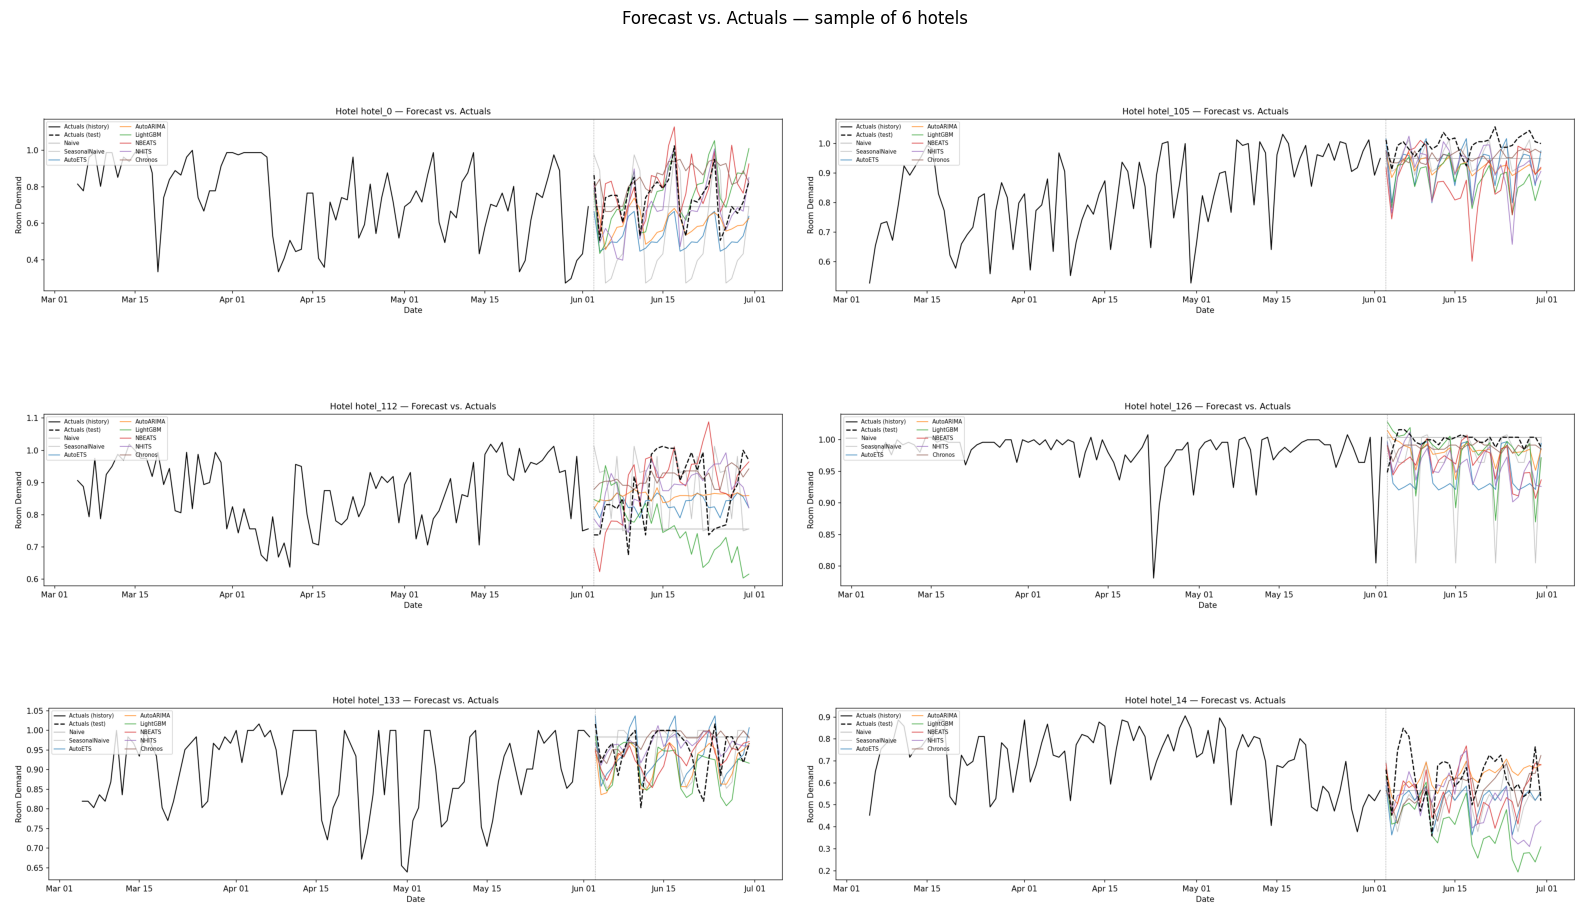

In [52]:
# ── Show first 6 plots inline ─────────────────────────────────────────────────
plot_files = sorted(PLOT_DIR.glob('*.png'))[:6]
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
for ax, pf in zip(axes.flatten(), plot_files):
    img = plt.imread(pf)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Forecast vs. Actuals — sample of 6 hotels', fontsize=12)
plt.tight_layout()
plt.show()

## 16. Summary & Conclusions

In [54]:
# ── Print an automatic narrative summary ──────────────────────────────────────
best_mae_overall = mae_flat.mean().idxmin()
best_rmse_overall = rmse_flat.mean().idxmin()
most_wins_mae = wins['MAE'].idxmax()

print("=" * 60)
print("SUMMARY OF FINDINGS")
print("=" * 60)
print(f"\n✅ Best average MAE  (CV): {best_mae_overall}")
print(f"✅ Best average RMSE (CV): {best_rmse_overall}")
print(f"✅ Most series won on MAE: {most_wins_mae}")

print("\n--- Average CV metrics across all 17 series ---")
summary_cv = pd.DataFrame({
    'MAE':  mae_flat.mean(),
    'RMSE': rmse_flat.mean(),
    'ME':   me_flat.mean(),
    'MAPE': mape_flat.mean() if use_mape else np.nan,
}).round(3)
print(summary_cv.sort_values('MAE').to_string())
summary_cv.to_csv('cv_summary_by_model.csv')
print("\nSaved: cv_summary_by_model.csv")

print("\n--- MAPE note ---")
if not use_mape:
    print("MAPE was NOT reported because some series contain zero demand values,")
    print("which would produce undefined (infinite) MAPE. MAE and RMSE are preferred.")
else:
    print("MAPE was computed for all series (no zeros detected).")

print("\n--- Output files ---")
for f in ['cv_results_per_series.csv', 'cv_win_counts.csv',
          'test_forecasts.csv', 'test_metrics_per_series.csv',
          'test_metrics_summary.csv', 'cv_summary_by_model.csv']:
    print(f"  📄 {f}")
print(f"  🖼️  forecast_plots/ ({n_series} PNG files)")

---
## Output Files Checklist

| File | Description |
|---|---|
| `cv_results_per_series.csv` | ME, MAE, RMSE, MAPE per series per model (CV) |
| `cv_win_counts.csv` | How often each model wins per metric |
| `cv_summary_by_model.csv` | Mean CV metrics across all series |
| `test_forecasts.csv` | Final test predictions (all models) |
| `test_metrics_per_series.csv` | Test set metrics per series per model |
| `test_metrics_summary.csv` | Mean test metrics across all series |
| `forecast_plots/*.png` | Forecast vs. actual plot for each hotel |
| `win_counts_heatmap.png` | Heatmap of model win counts |
| `eda_all_series.png` | EDA time-series overview |

> **Packages used:** `statsforecast`, `mlforecast`, `neuralforecast`, `chronos-forecasting` — all from the Nixtla / TimeCoPilot ecosystem. No `statsmodels` used.